In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ml_library import KNN, train_test_split, z_score_normalization

In [2]:
df = pd.read_csv("./dataset/train_binary.csv")
df.shape

(50000, 26)

In [3]:
df.sample(5)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,label
4612,552.415333,0.492221,4545.329561,61.449196,0.006717,60105.597023,536.908029,0.453355,4028.477834,31.762144,...,51.649068,1.136155,2490.106761,124.627726,0.709556,1357.412567,0.895093,1.735171,-1.0,1
40625,325.901298,0.498446,5279.293054,98.189240,0.003584,52132.282001,305.915133,0.461438,4561.358761,87.585800,...,104.975519,1.087552,2480.645309,94.014238,0.516744,2474.868794,0.281631,-0.301848,1.0,0
33242,509.648688,0.486610,5001.480465,19.152886,0.005839,61512.386686,489.328521,0.448772,4481.037837,35.437411,...,48.396281,1.021644,2004.330855,145.506529,0.784470,1814.075041,1.616943,0.965546,-1.0,1
27711,475.741510,0.509565,4791.825939,34.426858,0.004617,48139.204164,459.853482,0.468571,4185.738967,14.939105,...,73.997744,1.048973,2624.112272,153.657771,0.732131,1610.191593,1.327882,0.071316,-1.0,1
27230,650.520722,0.527967,4278.558017,91.851002,0.004044,43952.595252,606.877563,0.480645,3755.436147,82.799248,...,73.112205,0.955544,2515.294155,112.415607,0.556035,2116.478145,0.739622,0.578430,1.0,0


In [4]:
X = df.drop("label", axis=1).values
y = df["label"].values

X.shape, y.shape

((50000, 25), (50000,))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train = z_score_normalization(X_train)
X_test = z_score_normalization(X_test)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40000, 25), (10000, 25), (40000,), (10000,))

In [6]:
model = KNN(k=3)

model.fit(X_train, y_train)

In [7]:
y_pred = model.predict(X_test)
y_pred

array([1, 0, 1, ..., 0, 0, 1], shape=(10000,))

In [8]:
y_test

array([1, 0, 1, ..., 0, 0, 1], shape=(10000,))

Accuracy: 0.9967
Precision: 0.9970520799213888
Recall: 0.9921773142112125
F1 Score: 0.9946087240646954
Confusion Matrix:
[[6923    9]
 [  24 3044]]


(np.float64(0.9967),
 np.float64(0.9970520799213888),
 np.float64(0.9921773142112125),
 np.float64(0.9946087240646954),
 array([[6923,    9],
        [  24, 3044]]))

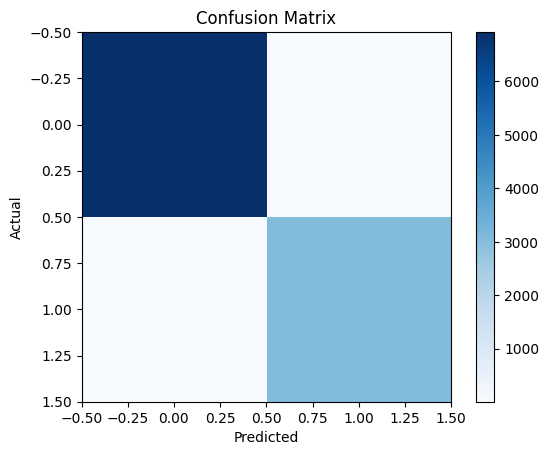

In [9]:
model.evaluation_metrics(y_test, y_pred)

In [10]:
df_testing = pd.read_csv("./dataset/test_binary.csv")

df_testing

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24
0,425.961417,0.499021,5534.216993,158.937483,0.003203,40326.757559,392.911630,0.462618,4839.965545,109.779291,...,8.662481,48.159841,1.055733,2512.532685,81.660268,0.389696,722.416800,1.294156,1.738285,1.0
1,621.169873,0.491361,5451.920192,134.151060,0.004912,46801.608384,586.622737,0.451685,4652.116744,123.802102,...,11.053048,89.110342,1.121912,2878.217512,193.418479,0.367436,1044.469536,0.818993,0.028234,-1.0
2,674.759463,0.497538,4353.708167,144.341660,0.005261,18439.406062,641.720752,0.460264,3963.570118,130.214181,...,13.257430,52.844750,0.976829,2379.556453,208.435965,0.344384,377.734099,1.097345,-0.824431,-1.0
3,555.548489,0.515458,5888.622134,126.766461,0.004454,31774.488278,536.516886,0.474615,5151.605518,94.595414,...,7.519873,115.401214,0.701615,2546.142182,170.688107,0.327638,588.388582,1.037413,0.995409,1.0
4,561.974757,0.494302,5505.669060,109.243006,0.004877,58478.356459,540.144512,0.458056,4862.586548,85.480364,...,7.935664,83.822568,0.801240,2843.177513,239.436877,0.310055,388.434472,0.538400,-0.104211,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,492.723517,0.508662,5913.560355,159.344707,0.005206,54738.158242,472.457007,0.469517,5219.057366,133.117911,...,2.876888,35.088249,0.906149,3300.631174,117.399049,0.378656,788.766705,1.497768,0.097543,-1.0
24996,427.980083,0.499640,3088.382135,92.470930,0.005529,42826.666529,405.896878,0.457697,2745.779108,78.236226,...,8.545169,103.853761,0.960669,2268.050480,113.605043,0.356656,-65.037414,1.917539,-0.379734,1.0
24997,511.624714,0.501069,4948.344231,149.472715,0.007314,44378.616919,473.186438,0.466215,4375.207300,112.984714,...,3.553127,65.697733,0.912177,3161.442108,222.277273,0.308293,1716.849179,0.990802,-1.300893,1.0
24998,644.839477,0.490971,4749.692049,127.073830,0.006809,41178.412309,610.546281,0.450768,4186.151345,102.987013,...,12.076402,55.298350,0.996310,1934.044611,164.819798,0.294823,1227.886470,0.596532,-1.595415,-1.0


In [11]:
X_testing = df_testing.copy().values
X_testing = z_score_normalization(X_testing)
X_testing.shape

(25000, 25)

In [ ]:
y_pred_test = model.predict(X_testing)

y_pred_test

In [ ]:
df_testing["target"] = y_pred_test
df_testing.to_csv("./output/knn_binary_class.csv", index=False)